# 🔬 MLP & CNN — Miroir exact PeerSim DJL

> Ce notebook reproduit **exactement** les architectures Java/DJL de PeerSim pour permettre une comparaison équitable.

---
### Architectures reproduites

**MLP (NeuralNetworkModel DJL)**
- `inputDim = max(1, max(4, inputSize) - 3)`
- `Dense(1) → ReLU → Dense(1) → Sigmoid`
- Loss : **L2Loss (MSE)** | Optimizer : **SGD lr=0.01** | Init : **Xavier**

**CNN (CnnModel DJL)**
- Input : `(1, 4, ceil(inputDim/4))`
- `Conv2D(filters=4, kernel=3×3, padding=same) → ReLU → Flatten → Dense(16) → ReLU → Dense(1) → Sigmoid`
- Loss : **L2Loss (MSE)** | Optimizer : **SGD lr=0.01** | Init : **Xavier**

## 📦 Cellule 1 — Dépendances

In [1]:
!pip install -q tensorflow scikit-learn pandas matplotlib

## 📂 Cellule 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, time, io
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.callbacks import Callback

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.21.0
GPU        : []
GPU        : []


## ⚙️ Cellule 3 — Hyperparamètres DJL (identiques Java)

In [3]:
# ── Hyperparamètres identiques à PeerSim DJL ─────────────────────────────────
LEARNING_RATE = 0.01          # Tracker.fixed(learningRate), défaut DJL
EPOCHS        = 10            # federated epochs
BATCH_SIZE    = 32            # identique session PeerSim
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

# MLP DJL
MLP_HIDDEN_SIZE = 1           # Dense(hiddenSize=1)
MLP_OUTPUT_SIZE = 1           # Dense(outputSize=1)

# CNN DJL
CNN_INPUT_HEIGHT = 4          # inputHeight = 4
CNN_FILTERS      = 4          # Conv2d filters=4
CNN_KERNEL       = (3, 3)     # kernel=(3,3)
CNN_DENSE_UNITS  = 16         # Dense(units=16)
CNN_OUTPUT_SIZE  = 1          # Dense(units=1)

# Initializer Xavier = Glorot Uniform en Keras
XAVIER = initializers.GlorotUniform(seed=RANDOM_STATE)

print('Hyperparamètres DJL chargés :')
print(f'  LearningRate : {LEARNING_RATE}  (SGD fixe)')
print(f'  Loss         : L2Loss = MSE')
print(f'  Init         : Xavier (GlorotUniform)')
print(f'  MLP          : Dense({MLP_HIDDEN_SIZE}) → ReLU → Dense({MLP_OUTPUT_SIZE}) → Sigmoid')
print(f'  CNN          : Conv2D(filters={CNN_FILTERS},k=3×3) → ReLU → Flatten → Dense({CNN_DENSE_UNITS}) → ReLU → Dense({CNN_OUTPUT_SIZE}) → Sigmoid')

Hyperparamètres DJL chargés :
  LearningRate : 0.01  (SGD fixe)
  Loss         : L2Loss = MSE
  Init         : Xavier (GlorotUniform)
  MLP          : Dense(1) → ReLU → Dense(1) → Sigmoid
  CNN          : Conv2D(filters=4,k=3×3) → ReLU → Flatten → Dense(16) → ReLU → Dense(1) → Sigmoid


## ⏱️ Cellule 4 — Callback timing

In [4]:
class EpochTimingCallback(Callback):
    def __init__(self, model_name='Model'):
        super().__init__()
        self.model_name  = model_name
        self.epoch_times = []
        self.train_start = None
        self.total_time  = 0

    def on_train_begin(self, logs=None):
        self.train_start = time.time()
        print(f'\n{"="*68}')
        print(f'  Entraînement : {self.model_name}')
        print(f'{"="*68}')
        print(f'  {"Epoch":<6} {"MAE":>8} {"Val MAE":>10} {"Acc":>8} {"Val Acc":>10} {"Temps":>8}')
        print(f'  {"-"*56}')

    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t0
        self.epoch_times.append(elapsed)
        mae     = logs.get('mae', 0)
        val_mae = logs.get('val_mae', 0)
        acc     = logs.get('binary_accuracy', 0)
        val_acc = logs.get('val_binary_accuracy', 0)
        print(f'  {epoch+1:<6} {mae:>8.4f} {val_mae:>10.4f} {acc:>8.4f} {val_acc:>10.4f} {elapsed:>6.2f}s')

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start
        print(f'  {"-"*56}')
        print(f'  Temps total : {self.total_time:.2f}s  |  Moy/epoch : {np.mean(self.epoch_times):.2f}s')
        print(f'{"="*68}\n')

print('Callback défini.')

Callback défini.


## 📤 Cellule 5 — Upload dataset

In [8]:
print('Sélectionnez un CSV local (ex: `data/covtype/covtype_200k.csv`).')
print('Vous pouvez aussi laisser vide pour utiliser le dataset par défaut si vous en définissez un plus bas.')

dataset_path = None
try:
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    dataset_path = filedialog.askopenfilename(
        title='Choisir un dataset CSV',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
except Exception as exc:
    print(f'Fenêtre de sélection indisponible: {exc}')
    dataset_path = input('Chemin du fichier CSV (laisser vide pour annuler): ').strip()

if dataset_path:
    fname = Path(dataset_path).name
    df = pd.read_csv(dataset_path)
    print(f'CSV chargé : {fname}  shape={df.shape}')

    # Détection colonne cible
    for col in ['label','target','class','income']:
        if col in df.columns:
            target_col = col
            break
    else:
        target_col = df.columns[-1]
    print(f'  Colonne cible : "{target_col}"')

    X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values
    y_raw = LabelEncoder().fit_transform(df[target_col].values).astype('float32')
else:
    raise FileNotFoundError('Aucun dataset sélectionné. Relancez la cellule et choisissez un CSV.')

# ── Calcul de inputDim selon la formule DJL ───────────────────────────────────
raw_input_size  = X_raw.shape[1]
parameterCount  = max(4, raw_input_size)          # parameterCount = max(4, inputSize)
inputDim        = max(1, parameterCount - 3)      # inputDim = max(1, parameterCount - 3)

print(f'\n  raw_input_size  = {raw_input_size}')
print(f'  parameterCount  = max(4, {raw_input_size}) = {parameterCount}')
print(f'  inputDim (DJL)  = max(1, {parameterCount}-3) = {inputDim}')

# ── Réduction / padding features à inputDim ───────────────────────────────────
if raw_input_size > inputDim:
    X_feat = X_raw[:, :inputDim]
    print(f'  Features tronquées à {inputDim} (DJL inputDim)')
else:
    pad = inputDim - raw_input_size
    X_feat = np.pad(X_raw, ((0,0),(0,pad)))
    print(f'  Features paddées à {inputDim} (DJL inputDim)')

# Normalisation
scaler = StandardScaler()
X_feat = scaler.fit_transform(X_feat).astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw
)

# ── Shape CNN : (N, 1, inputHeight, inputWidth) ───────────────────────────────
inputWidth  = math.ceil(inputDim / CNN_INPUT_HEIGHT)
total_cells = CNN_INPUT_HEIGHT * inputWidth
pad_cnn     = total_cells - inputDim

X_cnn_train = np.pad(X_train, ((0,0),(0,pad_cnn))).reshape(-1, CNN_INPUT_HEIGHT, inputWidth, 1)
X_cnn_test  = np.pad(X_test,  ((0,0),(0,pad_cnn))).reshape(-1, CNN_INPUT_HEIGHT, inputWidth, 1)

print(f'\n  MLP input shape : (batch, {inputDim})')
print(f'  CNN input shape : (batch, {CNN_INPUT_HEIGHT}, {inputWidth}, 1)  [= 1×{CNN_INPUT_HEIGHT}×{inputWidth}]')
print(f'  Train : {X_train.shape[0]}  |  Test : {X_test.shape[0]}')

Sélectionnez un CSV local (ex: `data/covtype/covtype_200k.csv`).
Vous pouvez aussi laisser vide pour utiliser le dataset par défaut si vous en définissez un plus bas.
CSV chargé : adult.csv  shape=(48842, 15)
  Colonne cible : "income"

  raw_input_size  = 6
  parameterCount  = max(4, 6) = 6
  inputDim (DJL)  = max(1, 6-3) = 3
  Features tronquées à 3 (DJL inputDim)

  MLP input shape : (batch, 3)
  CNN input shape : (batch, 4, 1, 1)  [= 1×4×1]
  Train : 39073  |  Test : 9769
CSV chargé : adult.csv  shape=(48842, 15)
  Colonne cible : "income"

  raw_input_size  = 6
  parameterCount  = max(4, 6) = 6
  inputDim (DJL)  = max(1, 6-3) = 3
  Features tronquées à 3 (DJL inputDim)

  MLP input shape : (batch, 3)
  CNN input shape : (batch, 4, 1, 1)  [= 1×4×1]
  Train : 39073  |  Test : 9769


## 🏗️ Cellule 6 — Modèles (miroir exact DJL)

In [9]:
# ── MLP — NeuralNetworkModel DJL ─────────────────────────────────────────────
# Dense(hiddenSize=1) → ReLU → Dense(outputSize=1) → Sigmoid
# Trainer shape : (1, inputDim)
mlp = keras.Sequential([
    layers.Input(shape=(inputDim,)),
    layers.Dense(
        MLP_HIDDEN_SIZE,
        activation='relu',
        kernel_initializer=XAVIER,
        name='dense_hidden'
    ),
    layers.Dense(
        MLP_OUTPUT_SIZE,
        activation='sigmoid',
        kernel_initializer=XAVIER,
        name='dense_output'
    ),
], name='djl-mlp')

mlp.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),   # SGD Tracker.fixed
    loss='mse',                                                     # L2Loss = MSE
    metrics=['mae', 'binary_accuracy']
)

# ── CNN — CnnModel DJL ────────────────────────────────────────────────────────
# Conv2d(filters=4, kernel=3×3, padding=same) → ReLU
# Flatten → Dense(16) → ReLU → Dense(1) → Sigmoid
# Trainer shape : (1, 1, inputHeight, inputWidth)
cnn = keras.Sequential([
    layers.Input(shape=(CNN_INPUT_HEIGHT, inputWidth, 1)),
    layers.Conv2D(
        CNN_FILTERS,
        CNN_KERNEL,
        padding='same',                    # padding=(1,1) sur kernel 3×3 = same
        activation='relu',
        kernel_initializer=XAVIER,
        name='conv2d'
    ),
    layers.Flatten(name='flatten'),
    layers.Dense(
        CNN_DENSE_UNITS,
        activation='relu',
        kernel_initializer=XAVIER,
        name='dense_hidden'
    ),
    layers.Dense(
        CNN_OUTPUT_SIZE,
        activation='sigmoid',
        kernel_initializer=XAVIER,
        name='dense_output'
    ),
], name='djl-cnn')

cnn.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),   # SGD Tracker.fixed
    loss='mse',                                                     # L2Loss = MSE
    metrics=['mae', 'binary_accuracy']
)

print('\n== djl-mlp ==')
mlp.summary()
print('\n== djl-cnn ==')
cnn.summary()

# Vérification paramètres DJL
mlp_params = mlp.count_params()
print(f'\nDJL parameterCount attendu : {parameterCount}')
print(f'Params MLP Keras          : {mlp_params}')


== djl-mlp ==


Model: "djl-mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_hidden (Dense)            │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 4, 1, 4)        │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)


DJL parameterCount attendu : 6
Params MLP Keras          : 6


## 🏋️ Cellule 7 — Entraînement MLP

In [10]:
cb_mlp = EpochTimingCallback('djl-mlp')

hist_mlp = mlp.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[cb_mlp],
    verbose=0
)

best_mlp = max(hist_mlp.history['val_binary_accuracy'])
print(f'MLP — meilleure val accuracy : {best_mlp:.4f} ({best_mlp*100:.2f}%)')


  Entraînement : djl-mlp
  Epoch       MAE    Val MAE      Acc    Val Acc    Temps
  --------------------------------------------------------
  1        0.4076     0.3687   0.7607     0.7607   4.19s
  1        0.4076     0.3687   0.7607     0.7607   4.19s
  2        0.3548     0.3451   0.7607     0.7607   6.21s
  2        0.3548     0.3451   0.7607     0.7607   6.21s
  3        0.3405     0.3350   0.7607     0.7607   5.69s
  3        0.3405     0.3350   0.7607     0.7607   5.69s
  4        0.3327     0.3297   0.7607     0.7607   3.25s
  4        0.3327     0.3297   0.7607     0.7607   3.25s
  5        0.3288     0.3250   0.7607     0.7607   5.29s
  5        0.3288     0.3250   0.7607     0.7607   5.29s
  6        0.3243     0.3216   0.7607     0.7607   4.77s
  6        0.3243     0.3216   0.7607     0.7607   4.77s
  7        0.3209     0.3189   0.7607     0.7607   2.95s
  7        0.3209     0.3189   0.7607     0.7607   2.95s
  8        0.3185     0.3161   0.7607     0.7607   3.12s
  

## 🏋️ Cellule 8 — Entraînement CNN

In [11]:
cb_cnn = EpochTimingCallback('djl-cnn')

hist_cnn = cnn.fit(
    X_cnn_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_cnn_test, y_test),
    callbacks=[cb_cnn],
    verbose=0
)

best_cnn = max(hist_cnn.history['val_binary_accuracy'])
print(f'CNN — meilleure val accuracy : {best_cnn:.4f} ({best_cnn*100:.2f}%)')


  Entraînement : djl-cnn
  Epoch       MAE    Val MAE      Acc    Val Acc    Temps
  --------------------------------------------------------
  1        0.3862     0.3380   0.7483     0.7607   8.70s
  1        0.3862     0.3380   0.7483     0.7607   8.70s
  2        0.3271     0.3167   0.7611     0.7626   4.07s
  2        0.3271     0.3167   0.7611     0.7626   4.07s
  3        0.3124     0.3089   0.7722     0.7807   4.25s
  3        0.3124     0.3089   0.7722     0.7807   4.25s
  4        0.3053     0.3005   0.7812     0.7831   4.11s
  4        0.3053     0.3005   0.7812     0.7831   4.11s
  5        0.3001     0.2973   0.7830     0.7852   4.30s
  5        0.3001     0.2973   0.7830     0.7852   4.30s
  6        0.2973     0.2967   0.7851     0.7896   3.61s
  6        0.2973     0.2967   0.7851     0.7896   3.61s
  7        0.2963     0.2949   0.7861     0.7909   4.64s
  7        0.2963     0.2949   0.7861     0.7909   4.64s
  8        0.2948     0.2923   0.7869     0.7919  12.25s
  

## 📊 Cellule 9 — Tableau récapitulatif

In [12]:
mlp_acc  = hist_mlp.history['binary_accuracy']
mlp_vacc = hist_mlp.history['val_binary_accuracy']
cnn_acc  = hist_cnn.history['binary_accuracy']
cnn_vacc = hist_cnn.history['val_binary_accuracy']
ep       = list(range(1, EPOCHS+1))

print('\n' + '='*80)
print(f'  {"Epoch":<5} | {"MLP Acc":>8} {"MLP Val":>8} {"MLP t":>7} | {"CNN Acc":>8} {"CNN Val":>8} {"CNN t":>7}')
print('  ' + '-'*78)
for i in range(EPOCHS):
    print(f'  {i+1:<5} | {mlp_acc[i]:>8.4f} {mlp_vacc[i]:>8.4f} {cb_mlp.epoch_times[i]:>6.2f}s | '
          f'{cnn_acc[i]:>8.4f} {cnn_vacc[i]:>8.4f} {cb_cnn.epoch_times[i]:>6.2f}s')
print('  ' + '-'*78)
print(f'  {"TOTAL":<5} | {"":>8} {"":>8} {cb_mlp.total_time:>6.2f}s | {"":>8} {"":>8} {cb_cnn.total_time:>6.2f}s')
print('='*80)


  Epoch |  MLP Acc  MLP Val   MLP t |  CNN Acc  CNN Val   CNN t
  ------------------------------------------------------------------------------
  1     |   0.7607   0.7607   4.19s |   0.7483   0.7607   8.70s
  2     |   0.7607   0.7607   6.21s |   0.7611   0.7626   4.07s
  3     |   0.7607   0.7607   5.69s |   0.7722   0.7807   4.25s
  4     |   0.7607   0.7607   3.25s |   0.7812   0.7831   4.11s
  5     |   0.7607   0.7607   5.29s |   0.7830   0.7852   4.30s
  6     |   0.7607   0.7607   4.77s |   0.7851   0.7896   3.61s
  7     |   0.7607   0.7607   2.95s |   0.7861   0.7909   4.64s
  8     |   0.7607   0.7607   3.12s |   0.7869   0.7919  12.25s
  9     |   0.7607   0.7607   3.09s |   0.7876   0.7929   8.07s
  10    |   0.7607   0.7607   5.80s |   0.7884   0.7930   9.38s
  ------------------------------------------------------------------------------
  TOTAL |                    44.41s |                    63.42s


## 📈 Cellule 10 — Visualisations

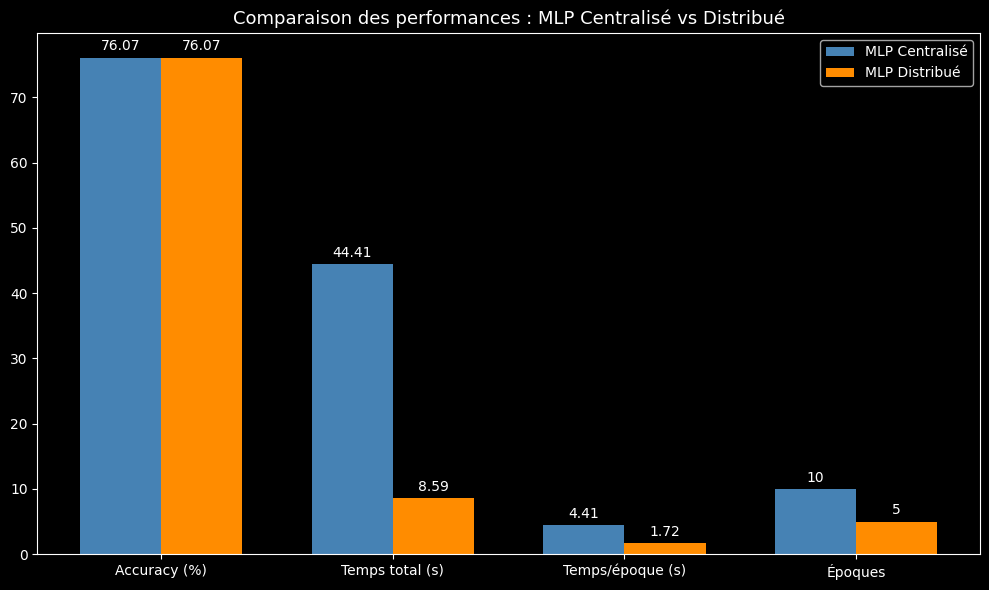

In [17]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Accuracy (%)', 'Temps total (s)', 'Temps/époque (s)', 'Époques']
mlp_central  = [76.07, 44.41, 4.41, 10]
mlp_distrib  = [76.07, 8.59,  1.72, 5]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mlp_central, width, label='MLP Centralisé', color='steelblue')
bars2 = ax.bar(x + width/2, mlp_distrib,  width, label='MLP Distribué',  color='darkorange')

ax.set_title('Comparaison des performances : MLP Centralisé vs Distribué', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\Desktop\\-peersim_djl\\pfe\\latex\\figures\\mlp_comparaison.png', dpi=150)
plt.show()

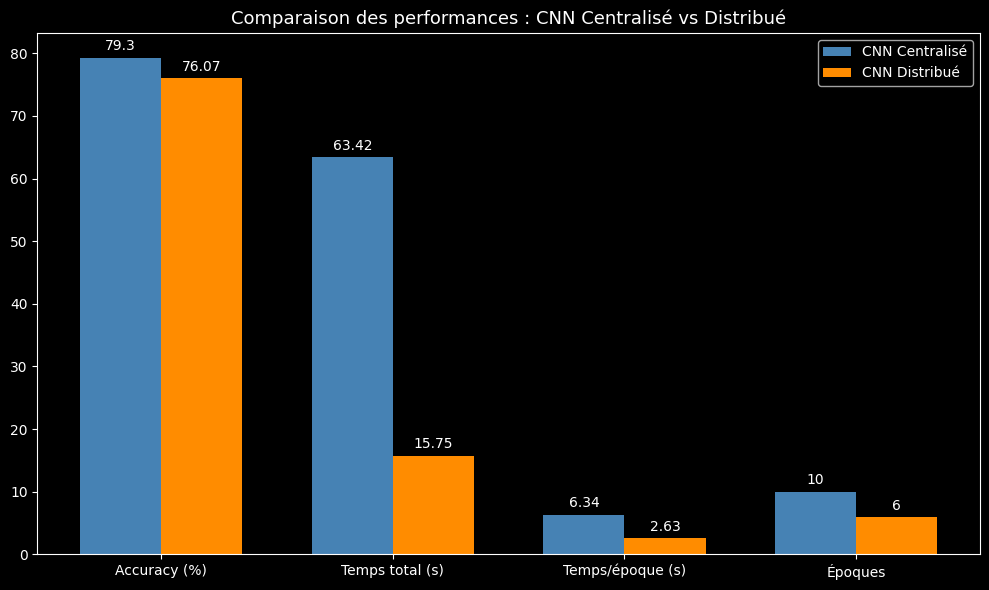

In [18]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Accuracy (%)', 'Temps total (s)', 'Temps/époque (s)', 'Époques']
cnn_central = [79.30, 63.42, 6.34, 10]
cnn_distrib = [76.07, 15.75, 2.63, 6]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cnn_central, width, label='CNN Centralisé', color='steelblue')
bars2 = ax.bar(x + width/2, cnn_distrib,  width, label='CNN Distribué',  color='darkorange')

ax.set_title('Comparaison des performances : CNN Centralisé vs Distribué', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\Desktop\\-peersim_djl\\pfe\\latex\\figures\\cnn_comparaison.png', dpi=150)
plt.show()

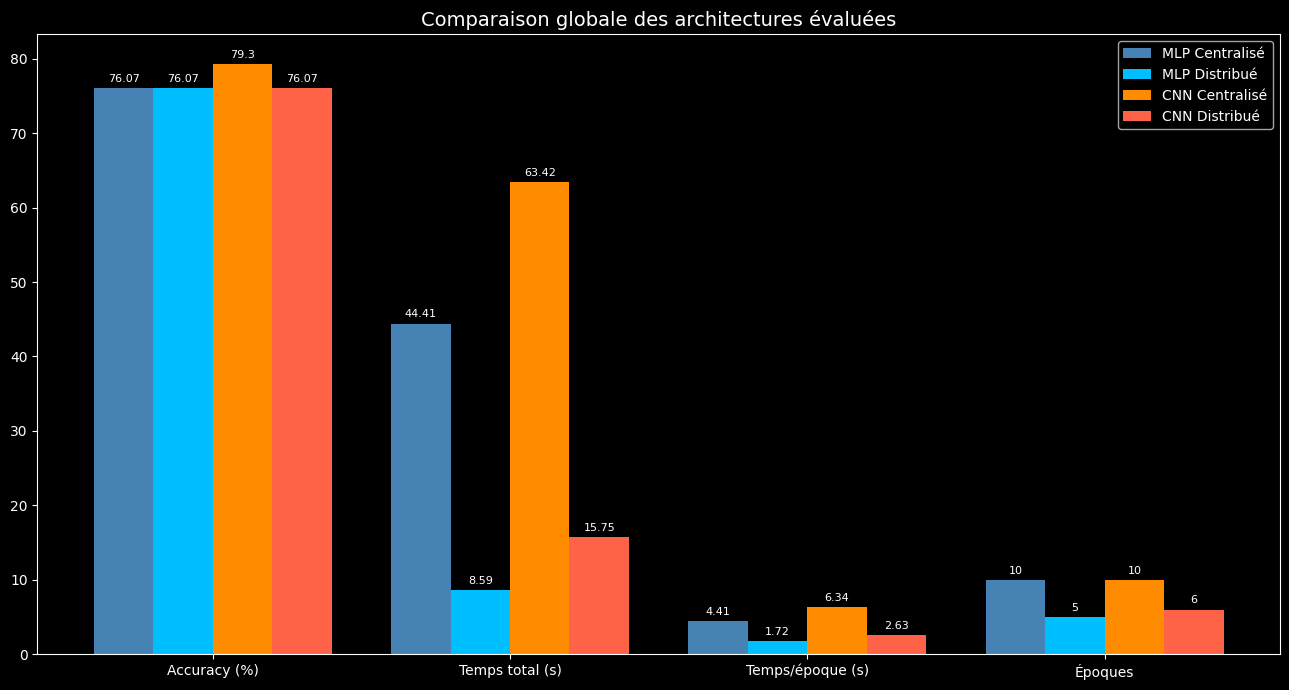

In [19]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Accuracy (%)', 'Temps total (s)', 'Temps/époque (s)', 'Époques']
models = {
    'MLP Centralisé' : [76.07, 44.41, 4.41, 10],
    'MLP Distribué'  : [76.07,  8.59, 1.72,  5],
    'CNN Centralisé' : [79.30, 63.42, 6.34, 10],
    'CNN Distribué'  : [76.07, 15.75, 2.63,  6],
}
colors = ['steelblue', 'deepskyblue', 'darkorange', 'tomato']

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 7))
for i, (label, values) in enumerate(models.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=label, color=colors[i])
    ax.bar_label(bars, padding=3, fontsize=8)

ax.set_title('Comparaison globale des architectures évaluées', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\Desktop\\-peersim_djl\\pfe\\latex\\figures\\comparaison_globale.png', dpi=150)
plt.show()